Project: CTCs

  m = 1  (7 qubits)
  pytket circuit: 7q / 3 bits
  Uploaded: DCTC_m1_benchmark
  Job submitted: 6e3535eb-bcdc-4be8-b966-5c8fe147af07
  Waiting. COMPLETED
  Downloaded compiled circuit
  N_2q=28  d=100  d_2q=18
  Saved to dctc_compiled_metrics.json

  m = 2  (14 qubits)
  pytket circuit: 14q / 6 bits
  Uploaded: DCTC_m2_benchmark
  Job submitted: ea409175-7d4f-4686-9148-c89971f2e91b
  Waiting. COMPLETED
  Downloaded compiled circuit
  N_2q=56  d=190  d_2q=18
  Saved to dctc_compiled_metrics.json

  m = 3  (21 qubits)
  pytket circuit: 21q / 9 bits
  Uploaded: DCTC_m3_benchmark
  Job submitted: f60d3adc-dae3-415c-a1fe-2c776fc5c571
  Waiting.. COMPLETED
  Downloaded compiled circuit
  N_2q=84  d=280  d_2q=18
  Saved to dctc_compiled_metrics.json

=== Compiled Metrics ===
  m=1:  N_2q=28  N_1q=156  d=100  d_2q=18
  m=2:  N_2q=56  N_1q=312  d=190  d_2q=18
  m=3:  N_2q=84  N_1q=468  d=280  d_2q=18

Gate inventories:
  m=1: {'OpType.Rz': 78, 'OpType.PhasedX': 78, 'OpType.Barri

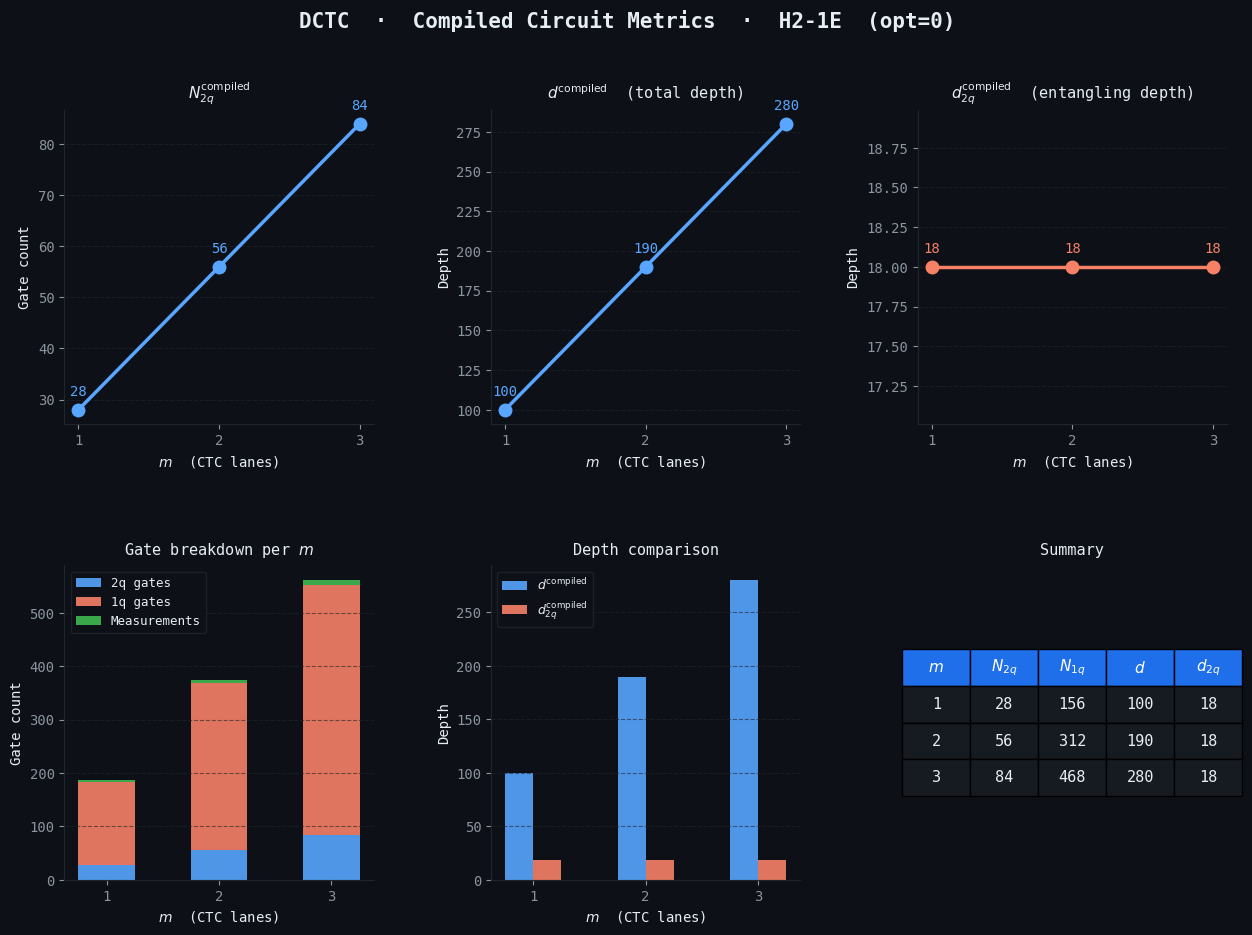

In [5]:
"""
dctc_benchmark_compiled.py
==========================
Runs compile jobs for DCTC circuits m=1,2,3 on Helios-1E,
extracts compiled metrics, stores results as JSON, and plots figures.

Usage:  python dctc_benchmark_compiled.py
        python dctc_benchmark_compiled.py --skip-compile   # re-plot from saved JSON
"""

import time
import json
import sys
from collections import Counter
from math import pi

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

import qnexus as qnx
from pytket.extensions.qiskit import qiskit_to_tk
from pytket.circuit import OpType
from pytket import Circuit as TKCircuit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

# ── Config ────────────────────────────────────────────────────────────────────
PROJECT_NAME  = "CTCs"
BACKEND       = "H2-1E"
OPT_LEVEL     = 0
RESULTS_FILE  = "pctc_compiled_metrics.json"
M_VALUES      = [1, 2, 3]

# Native 2q gate types for Helios-1E
TWO_Q_TYPES = {
    OpType.ZZMax, OpType.ZZPhase, OpType.PhasedISWAP,
    OpType.ISWAP, OpType.CX, OpType.CZ
}

# ── Circuit builder ───────────────────────────────────────────────────────────
def build_dctc(n: int, msg_params=None):
    if msg_params is None:
        msg_params = [(0.5, 0.2, 0.1)] * n

    C = QuantumRegister(n, 'qc');  E = QuantumRegister(n, 'qe')
    R = QuantumRegister(n, 'qr');  G = QuantumRegister(n, 'qg')
    M = QuantumRegister(n, 'qm');  A = QuantumRegister(n, 'qa')
    Y = QuantumRegister(n, 'qy')
    crR = ClassicalRegister(n, 'crr')
    crG = ClassicalRegister(n, 'crg')
    crC = ClassicalRegister(n, 'crc')

    qc = QuantumCircuit(C, E, R, G, M, A, Y, crR, crG, crC)

    for i, (theta, phi, lam) in enumerate(msg_params):
        qc.u(theta, phi, lam, M[i])
    for i in range(n):
        qc.swap(C[i], M[i])
    qc.barrier()
    for i in range(n):
        qc.h(E[i]); qc.cx(E[i], M[i])
        qc.h(R[i]); qc.cx(R[i], G[i])
        qc.h(A[i]); qc.cx(A[i], Y[i])
    qc.barrier()
    for i in range(n):
        qc.cz(C[i], R[i]); qc.cz(E[i], R[i]); qc.cz(C[i], E[i])
        qc.h(C[i]); qc.h(E[i]); qc.h(R[i])
        qc.cz(C[i], R[i]); qc.cz(C[i], E[i]); qc.cz(E[i], R[i])
        qc.barrier()
    for i in range(n):
        qc.cz(A[i], G[i]); qc.cz(M[i], A[i]); qc.cz(G[i], M[i])
        qc.h(A[i]); qc.h(M[i]); qc.h(G[i])
        qc.cz(A[i], G[i]); qc.cz(G[i], M[i]); qc.cz(M[i], A[i])
        qc.barrier()
    for i in range(n):
        qc.rz(pi, R[i]); qc.rx(pi, R[i])
        qc.rx(pi, G[i]); qc.swap(R[i], G[i])
        qc.rz(pi, R[i]); qc.barrier()
    for i in range(n):
        qc.cz(A[i], G[i]); qc.cz(M[i], A[i]); qc.cz(G[i], M[i])
        qc.h(A[i]); qc.h(M[i]); qc.h(G[i])
        qc.cz(A[i], G[i]); qc.cz(G[i], M[i]); qc.cz(M[i], A[i])
        qc.barrier()
    for i in range(n):
        qc.rz(pi, A[i]); qc.rx(pi, A[i])
        qc.rx(pi, Y[i]); qc.swap(A[i], Y[i])
        qc.rz(pi, A[i]); qc.barrier()
    for i in range(n):
        qc.cz(A[i], G[i]); qc.cz(M[i], A[i]); qc.cz(G[i], M[i])
        qc.h(A[i]); qc.h(M[i]); qc.h(G[i])
        qc.cz(A[i], G[i]); qc.cz(G[i], M[i]); qc.cz(M[i], A[i])
        qc.barrier()
    for i in range(n):
        qc.cx(R[i], G[i]); qc.h(R[i])
        qc.measure(R[i], crR[i]); qc.measure(G[i], crG[i])
        qc.barrier()
    for i in range(n):
        qc.swap(C[i], Y[i])
    for i, (theta, phi, lam) in enumerate(msg_params):
        qc.u(theta, phi, lam, C[i]).inverse()
    for i in range(n):
        qc.measure(C[i], crC[i])

    return qc


# ── Metric extraction from compiled pytket circuit ────────────────────────────
def extract_metrics(compiled_tk, m: int) -> dict:
    cmds = compiled_tk.get_commands()

    n2q  = sum(1 for c in cmds if c.op.type in TWO_Q_TYPES)
    n1q  = sum(1 for c in cmds if len(c.args) == 1
                                and c.op.type != OpType.Measure
                                and c.op.type != OpType.Reset)
    nmeas = sum(1 for c in cmds if c.op.type == OpType.Measure)
    ntot  = sum(1 for c in cmds if c.op.type != OpType.Barrier)
    d     = compiled_tk.depth()

    # 2q-only depth
    sub = TKCircuit(compiled_tk.n_qubits, compiled_tk.n_bits)
    for c in cmds:
        if c.op.type in TWO_Q_TYPES:
            sub.add_gate(c.op.type, c.op.params, c.args)
    d_2q = sub.depth()

    gate_inventory = dict(Counter(str(c.op.type) for c in cmds))

    return {
        "m":              m,
        "n_qubits":       compiled_tk.n_qubits,
        "N_2q_compiled":  n2q,
        "N_1q_compiled":  n1q,
        "N_meas":         nmeas,
        "N_gates_total":  ntot,
        "d_compiled":     d,
        "d_2q_compiled":  d_2q,
        "gate_inventory": gate_inventory,
    }


# ── Compile + collect for one m ───────────────────────────────────────────────
def run_single(m: int, project) -> dict:
    print(f"\n{'='*50}")
    print(f"  m = {m}  ({7*m} qubits)")
    print(f"{'='*50}")

    # Build & convert
    qc = build_dctc(n=m)
    tk_circ = qiskit_to_tk(qc)
    print(f"  pytket circuit: {tk_circ.n_qubits}q / {tk_circ.n_bits} bits")

    # Upload
    circuit_ref = qnx.circuits.upload(
        name=f"DCTC_m{m}_benchmark",
        circuit=tk_circ,
        project=project,
    )
    print(f"  Uploaded: {circuit_ref.annotations.name}")

    # Compile
    compile_job = qnx.start_compile_job(
        programs=circuit_ref,
        backend_config=qnx.QuantinuumConfig(device_name=BACKEND),
        optimisation_level=OPT_LEVEL,
        name=f"DCTC_m{m}_benchmark",
        project=project,
    )
    print(f"  Job submitted: {compile_job.id}")

    # Poll
    print(f"  Waiting", end="", flush=True)
    while True:
        status = qnx.jobs.status(compile_job)
        if status.status.value in ("COMPLETED", "ERROR", "CANCELLED"):
            break
        print(".", end="", flush=True)
        time.sleep(5)
    print(f" {status.status.value}")

    if status.status.value != "COMPLETED":
        raise RuntimeError(f"Compile job failed for m={m}: {status}")

    # Download compiled circuit
    compiled_tk = qnx.jobs.results(compile_job)[0].get_output().download_circuit()
    print(f"  Downloaded compiled circuit")

    # Extract metrics
    metrics = extract_metrics(compiled_tk, m)
    print(f"  N_2q={metrics['N_2q_compiled']}  "
          f"d={metrics['d_compiled']}  "
          f"d_2q={metrics['d_2q_compiled']}")

    return metrics


# ── Main benchmark loop ───────────────────────────────────────────────────────
def run_benchmark(m_values=M_VALUES):
    project = qnx.projects.get(name=PROJECT_NAME)
    print(f"Project: {project.annotations.name}")

    results = []
    for m in m_values:
        metrics = run_single(m, project)
        results.append(metrics)

        # Save after each m so we don't lose data if something fails
        with open(RESULTS_FILE, "w") as f:
            json.dump(results, f, indent=2)
        print(f"  Saved to {RESULTS_FILE}")

    return results


# ── Plotting ──────────────────────────────────────────────────────────────────
def plot_results(results: list, save_path="dctc_compiled_figures.png"):
    m_vals  = [r["m"]             for r in results]
    n2q     = [r["N_2q_compiled"] for r in results]
    n1q     = [r["N_1q_compiled"] for r in results]
    nmeas   = [r["N_meas"]        for r in results]
    d_tot   = [r["d_compiled"]    for r in results]
    d_2q    = [r["d_2q_compiled"] for r in results]

    # ── Aesthetics ────────────────────────────────────────────────────────────
    BG      = "#0d1117"
    GRID    = "#21262d"
    C1      = "#58a6ff"   # blue  — 2q gates / total depth
    C2      = "#f78166"   # coral — 1q gates / 2q depth
    C3      = "#3fb950"   # green — measurements
    WHITE   = "#e6edf3"
    MUTED   = "#8b949e"

    plt.rcParams.update({
        "figure.facecolor":  BG,
        "axes.facecolor":    BG,
        "axes.edgecolor":    GRID,
        "axes.labelcolor":   WHITE,
        "xtick.color":       MUTED,
        "ytick.color":       MUTED,
        "text.color":        WHITE,
        "grid.color":        GRID,
        "grid.linestyle":    "--",
        "grid.alpha":        0.6,
        "font.family":       "monospace",
    })

    fig = plt.figure(figsize=(15, 10), facecolor=BG)
    fig.suptitle(
        f"DCTC  ·  Compiled Circuit Metrics  ·  {BACKEND}  (opt={OPT_LEVEL})",
        fontsize=15, fontweight="bold", color=WHITE, y=0.98
    )

    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

    # ── Panel helper ──────────────────────────────────────────────────────────
    def styled_ax(gs_pos, title):
        ax = fig.add_subplot(gs_pos)
        ax.set_title(title, fontsize=11, color=WHITE, pad=8)
        ax.set_xticks(m_vals)
        ax.set_xlabel("$m$  (CTC lanes)", fontsize=10)
        ax.grid(True, axis="y")
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["left", "bottom"]].set_color(GRID)
        return ax

    # ── 1. 2q gate count ─────────────────────────────────────────────────────
    ax1 = styled_ax(gs[0, 0], r"$N_{2q}^{\rm compiled}$")
    ax1.plot(m_vals, n2q, "o-", color=C1, lw=2.5, ms=9, zorder=3)
    for x, y in zip(m_vals, n2q):
        ax1.annotate(str(y), (x, y), textcoords="offset points",
                     xytext=(0, 10), ha="center", fontsize=10, color=C1)
    ax1.set_ylabel("Gate count", fontsize=10)

    # ── 2. Total depth ───────────────────────────────────────────────────────
    ax2 = styled_ax(gs[0, 1], r"$d^{\rm compiled}$  (total depth)")
    ax2.plot(m_vals, d_tot, "o-", color=C1, lw=2.5, ms=9, zorder=3)
    for x, y in zip(m_vals, d_tot):
        ax2.annotate(str(y), (x, y), textcoords="offset points",
                     xytext=(0, 10), ha="center", fontsize=10, color=C1)
    ax2.set_ylabel("Depth", fontsize=10)

    # ── 3. 2q depth ──────────────────────────────────────────────────────────
    ax3 = styled_ax(gs[0, 2], r"$d_{2q}^{\rm compiled}$  (entangling depth)")
    ax3.plot(m_vals, d_2q, "o-", color=C2, lw=2.5, ms=9, zorder=3)
    for x, y in zip(m_vals, d_2q):
        ax3.annotate(str(y), (x, y), textcoords="offset points",
                     xytext=(0, 10), ha="center", fontsize=10, color=C2)
    ax3.set_ylabel("Depth", fontsize=10)

    # ── 4. Stacked bar: gate breakdown ───────────────────────────────────────
    ax4 = styled_ax(gs[1, 0], "Gate breakdown per $m$")
    w = 0.5
    b1 = ax4.bar(m_vals, n2q,  w, label="2q gates",      color=C1,  alpha=0.9)
    b2 = ax4.bar(m_vals, n1q,  w, bottom=n2q,            label="1q gates",      color=C2,  alpha=0.9)
    b3 = ax4.bar(m_vals, nmeas, w, bottom=[a+b for a,b in zip(n2q, n1q)],
                 label="Measurements", color=C3, alpha=0.9)
    ax4.legend(fontsize=9, facecolor=BG, edgecolor=GRID, labelcolor=WHITE)
    ax4.set_ylabel("Gate count", fontsize=10)

    # ── 5. 2q vs total depth side by side ────────────────────────────────────
    ax5 = styled_ax(gs[1, 1], "Depth comparison")
    x    = np.array(m_vals)
    w2   = 0.25
    ax5.bar(x - w2/2, d_tot, w2, label=r"$d^{\rm compiled}$",     color=C1, alpha=0.9)
    ax5.bar(x + w2/2, d_2q,  w2, label=r"$d_{2q}^{\rm compiled}$", color=C2, alpha=0.9)
    ax5.legend(fontsize=9, facecolor=BG, edgecolor=GRID, labelcolor=WHITE)
    ax5.set_ylabel("Depth", fontsize=10)

    # ── 6. Summary table ─────────────────────────────────────────────────────
    ax6 = fig.add_subplot(gs[1, 2])
    ax6.axis("off")
    col_labels = ["$m$", "$N_{2q}$", "$N_{1q}$", "$d$", "$d_{2q}$"]
    cell_data  = [[str(r["m"]), str(r["N_2q_compiled"]), str(r["N_1q_compiled"]),
                   str(r["d_compiled"]), str(r["d_2q_compiled"])]
                  for r in results]
    tbl = ax6.table(cellText=cell_data, colLabels=col_labels,
                    cellLoc="center", loc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1.1, 2.2)
    for j in range(len(col_labels)):
        tbl[0, j].set_facecolor("#1f6feb")
        tbl[0, j].set_text_props(color="white", fontweight="bold")
    for i in range(1, len(results)+1):
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor("#161b22")
            tbl[i, j].set_text_props(color=WHITE)
    ax6.set_title("Summary", fontsize=11, color=WHITE, pad=8)

    plt.savefig(save_path, bbox_inches="tight", dpi=200, facecolor=BG)
    print(f"\nFigure saved → {save_path}")
    plt.show()


# ── Entry point ───────────────────────────────────────────────────────────────
if __name__ == "__main__":
    skip_compile = "--skip-compile" in sys.argv

    if skip_compile:
        # Re-plot from previously saved JSON
        print(f"Loading results from {RESULTS_FILE}...")
        with open(RESULTS_FILE) as f:
            results = json.load(f)
    else:
        results = run_benchmark(m_values=M_VALUES)

    print("\n=== Compiled Metrics ===")
    for r in results:
        print(f"  m={r['m']}:  N_2q={r['N_2q_compiled']}  "
              f"N_1q={r['N_1q_compiled']}  "
              f"d={r['d_compiled']}  d_2q={r['d_2q_compiled']}")

    print("\nGate inventories:")
    for r in results:
        print(f"  m={r['m']}: {r['gate_inventory']}")

    plot_results(results, save_path="dctc_compiled_figures.png")